github link: https://github.com/s234824dtu/compsocsci-assignment1

contributions:
all sections: equally shared between Aksel Mads Madsen (s234824) & Peter Møller Naur (s241554)

In [31]:
import pandas as pd
import networkx as nx
from itertools import product
import random
import community
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math
import numpy as np
from tqdm import tqdm
import pickle

In [2]:
D2 = pd.read_pickle("D2.pickle")
D5 = pd.read_pickle("D5.pickle")
D8 = pd.concat([D2, D5])

In [3]:
D1 = pd.read_pickle("D1.pickle")
D4 = pd.read_pickle("D4.pickle")
D7 = pd.concat([D1, D4])

In [4]:
D3 = pd.read_pickle("D3.pickle")
D6 = pd.read_pickle("D6.pickle")
D9 = pd.concat([D3, D6])

In [5]:
edge_dict = defaultdict(lambda: 0)
for author_ids in D8["author_ids"]:
    for (authors) in product(author_ids, repeat=2):
        if authors[0] is None or authors[1] is None:
            continue
        if authors[0] == authors[1] or authors[0] > authors[1]:
            continue
        edge_dict[(authors[0], authors[1])] +=1 
edge_list = [(author1, author2, w) for ((author1, author2), w) in edge_dict.items()]
node_list = list(D7["id"])

In [6]:
G = nx.Graph()
G.add_nodes_from(node_list) # nx implicitly adds the nodes when adding the edges, but some nodes have no edges
G.add_weighted_edges_from(edge_list)

In [7]:
attr_dict = {author["id"]: {attr_name: author[attr_name] for attr_name in ["display_name", "last_known_institutions.0.country_code"]} for author in D7.to_dict(orient="records")}
nx.set_node_attributes(G, attr_dict)

#attr_dict
G.nodes["https://openalex.org/A5032880777"]

{'display_name': 'Michaël Maes',
 'last_known_institutions.0.country_code': 'US'}

In [13]:
print(len(D7), (list(G.nodes)[200_000]))

42810 https://openalex.org/A5033572031


In [14]:
def assoc_coeff(network):
    e = defaultdict(lambda: 0)
    i = 0
    for (n1, n2) in network.edges():
        #i += 1
        #if i > 10000:
        #    break
        if not ("last_known_institutions.0.country_code" in G.nodes[n1] and "last_known_institutions.0.country_code" in G.nodes[n2]):
            continue
        countries = (G.nodes[n1]["last_known_institutions.0.country_code"], G.nodes[n2]["last_known_institutions.0.country_code"])
        if not (isinstance(countries[0], str) and isinstance(countries[1], str)):
            continue
        countries = tuple(sorted(countries))
        e[countries] += 1
    total = sum([co for co in e.values()])
    e = defaultdict(int, {countries: count/total for countries, count in e.items()})
    all_countries = list(set(c[0] for c in e.keys()).union(set(c[1] for c in e.keys())))
    a = [sum(e[(country_a, country_b)] for country_b in all_countries) for country_a in all_countries]
    b = [sum(e[(country_a, country_b)] for country_a in all_countries) for country_b in all_countries]
    sab = sum([ai * bi for (ai, bi) in zip(a, b)])
    return ((sum([e[c] for c in all_countries]) - sab) / (1 - sab))

In [15]:
assoc_coeff(G)

-0.16794957688178963

In [16]:
len(G.edges())

1143831

In [21]:
def doubleswap(g, n=10):
    g2 = g.copy()
    edges = list(g2.edges())
    m = len(edges)
    i = 0
    while i < (n * m):
        idx1 = random.randrange(m)
        idx2 = random.randrange(m)
        if idx1 == idx2:
            continue
        uorig, vorig = edges[idx1]
        x, y = edges[idx2]
        flip = random.choice([True, False])
        u, v = (vorig, uorig) if flip else (uorig, vorig)

        if u == y or v == x or g2.has_edge(u, x) or g2.has_edge(v, y):
            continue

        g2.remove_edge(uorig, vorig)
        g2.remove_edge(x, y)
        g2.add_edge(u, x)
        g2.add_edge(v, y)
        edges[idx1] = (u, x)
        edges[idx2] = (v, y)
        i += 1
    return g2

In [ ]:
swapped =  [doubleswap(G) for i in range(10)]

In [ ]:
def degree_assoc(g):
    degrees = dict(G.degree()) 
    n       = G.number_of_nodes()
    degree_counts = Counter(degrees.values())
    p = {k: cnt / n for k, cnt in degree_counts.items()}
    mean_k = sum(k * pk for k, pk in p.items())
    q = {k: k * pk / mean_k for k, pk in p.items()}
    sigma2 = (
        sum(k**2 * qk for k, qk in q.items())
        - sum(k  * qk for k, qk in q.items()) ** 2
    )
    total_edge_stubs = 2 * G.number_of_edges()
    e = {}
    for u, v in G.edges():
        ki, kj = degrees[u], degrees[v]
        for key in ((ki, kj), (kj, ki)):
            e[key] = e.get(key, 0.0) + 1.0 / total_edge_stubs

    r = sum(
        j * k * (ejk - q.get(j, 0.0) * q.get(k, 0.0))
        for (j, k), ejk in e.items()
    ) / sigma2

    return float(r)

In [ ]:
country_dist = [assoc_coeff(n) for n in tqdm(swapped)]

100%|██████████| 10/10 [00:11<00:00,  1.11s/it]


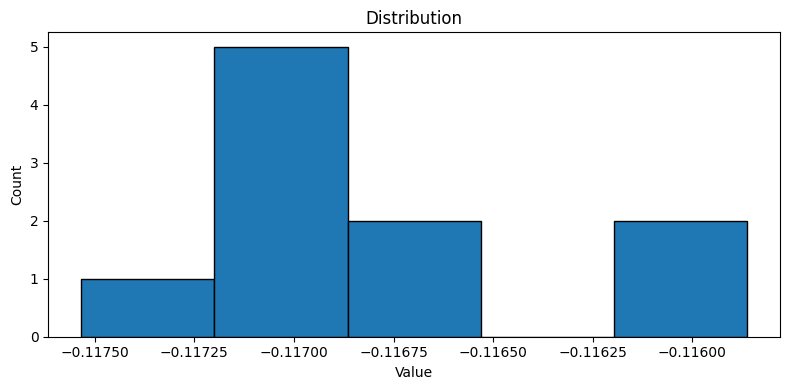

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(country_dist, bins=5, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Distribution")
plt.tight_layout()
plt.show()

In [ ]:
degree_dist = [degree_assoc(n) for n in tqdm(swapped)]

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:12<00:00,  1.26s/it]


In [ ]:
print(degree_assoc(G))
degree_dist

0.0038930294234713354


[0.0038930294234713354,
 0.0038930294234713354,
 0.0038930294234713354,
 0.0038930294234713354,
 0.0038930294234713354,
 0.0038930294234713354,
 0.0038930294234713354,
 0.0038930294234713354,
 0.0038930294234713354,
 0.0038930294234713354]

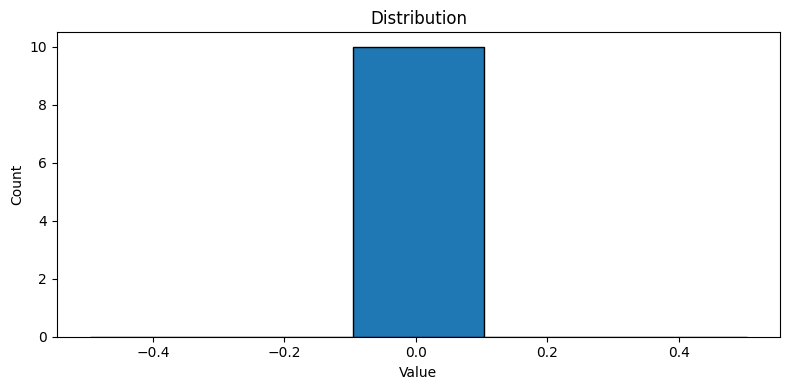

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(degree_dist, bins=5, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Distribution")
plt.tight_layout()
plt.show()

Our graph is undirected, so flipping edge direction should have no effect. However, if nodes items are systematically more likely to appear in the first position, then they get swapped disproportionally more with the kinds of nodes that are more likely to appear in the second position. This adds bias to the doubleswap function. Randomly flipping fixes this.

The difference in the assortiativity coefficient between the randomly swapped networks with same show that authors are a lot more likely to assosciate with others of the same country than would be expected in a random case. This is expected.

Since the degree of each node is fixed by the configuration model, the degree assortiativity will by definition not be changed by the the doubleswap procedure.

We expect that randomly generating new graphs according to the configuration model would result in graphs that are neutrally assosciated. Since it would be very weird if scientists dissorted by country, we expect the doubleswap procedure to reduce assortiativity.

# Part 2: TF-IDF

TF-IDF is a summary value of a document in some corpus based on the disproportionate frequency of some token in the document, relative to the rest of the corpus.

TF is the Term Frequency is the fraction of tokens within some document that are of a specific token type. TF is specific to a token-document pair, and ignores the rest of the corpus.
IDF is the Inverse Document Frequency and is the log of the inverse fraction of documents in which some term appears. An IDF valuee is assosciated with a pair of a token and an entire corpus.

TF-IDf is just their product.

In [8]:
D3 = pd.read_pickle("D3.pickle")
D6 = pd.read_pickle("D6.pickle")
D9 = pd.concat([D3, D6])
D9 = D9.dropna(subset="abstract_inverted_index")

In [9]:
D2 = pd.read_pickle("D2.pickle")
D5 = pd.read_pickle("D5.pickle")
D8 = pd.concat([D2, D5])

D1 = pd.read_pickle("D1.pickle")
D4 = pd.read_pickle("D4.pickle")
D7 = pd.concat([D1, D4])

In [10]:
import re

def to_abswords(abs_inv_idx):
    abswords = []
    for word, _ in abs_inv_idx.items():
        abswords.append(re.sub(r"[\W]+", "", word.lower()))
    return abswords

D9["tokens"] = D9["abstract_inverted_index"].apply(to_abswords)

In [11]:
communities = community.best_partition(G)
communities

{'https://openalex.org/A5017981514': 0,
 'https://openalex.org/A5051891666': 1,
 'https://openalex.org/A5032880777': 2,
 'https://openalex.org/A5053982410': 3,
 'https://openalex.org/A5084087666': 4,
 'https://openalex.org/A5025218537': 5,
 'https://openalex.org/A5073270600': 6,
 'https://openalex.org/A5100448217': 7,
 'https://openalex.org/A5035455593': 8,
 'https://openalex.org/A5009049500': 9,
 'https://openalex.org/A5019962493': 10,
 'https://openalex.org/A5003636926': 6,
 'https://openalex.org/A5050750056': 11,
 'https://openalex.org/A5063441605': 12,
 'https://openalex.org/A5011855937': 13,
 'https://openalex.org/A5086011172': 5,
 'https://openalex.org/A5122308898': 14,
 'https://openalex.org/A5025695582': 13,
 'https://openalex.org/A5047721170': 15,
 'https://openalex.org/A5090107603': 16,
 'https://openalex.org/A5031295007': 13,
 'https://openalex.org/A5023817571': 17,
 'https://openalex.org/A5097605722': 18,
 'https://openalex.org/A5041467283': 19,
 'https://openalex.org/A5043

In [34]:
with open("community_assignment.pkl", "wb") as f:
    pickle.dump(communities, f)

In [12]:
print(communities["https://openalex.org/A5122308898"])

G.nodes["https://openalex.org/A5122308898"]

14


{'display_name': 'Michalina Janik',
 'last_known_institutions.0.country_code': nan}

In [13]:
D7["com"] = D7["id"].map(communities)
D7

,id,display_name,works_api_url,summary_stats.h_index,works_count,last_known_institutions.0.country_code,com
0,https://openalex.org/A5017981514,Kohei Takeda,https://api.openalex.org/works?filter=author.i...,23,169,SG,0
1,https://openalex.org/A5051891666,Florian Keusch,https://api.openalex.org/works?filter=author.i...,25,122,DE,1
2,https://openalex.org/A5032880777,Michaël Maes,https://api.openalex.org/works?filter=author.i...,141,1385,US,2
3,https://openalex.org/A5053982410,Fábio Sartori,https://api.openalex.org/works?filter=author.i...,14,129,IT,3
4,https://openalex.org/A5084087666,Wanting Wang,https://api.openalex.org/works?filter=author.i...,22,152,CN,4
...,...,...,...,...,...,...,...
41899,https://openalex.org/A5015683910,Ij.H. van Emmerik-Kats,https://api.openalex.org/works?filter=author.i...,1,2,NaN,64
41900,https://openalex.org/A5075825851,Jing Kong,https://api.openalex.org/works?filter=author.i...,139,856,CN,220
41901,https://openalex.org/A5027146586,Joshua E. Goldberger,https://api.openalex.org/works?filter=author.i...,47,188,US,220
41902,https://openalex.org/A5013179110,Lei Qi,https://api.openalex.org/works?filter=author.i...,10,32,CN,85


In [14]:
df = D8.merge(D9, on="id")
df = df.explode("author_ids")
df = df.merge(D7, left_on="author_ids", right_on="id")
community_tokens = (
    df.groupby("com")["tokens"]
      .apply(lambda tokenss: [token
                              for tokens in tokenss
                              for token in tokens])
      .reset_index()
)

In [15]:
n_authors = (D7.groupby("com").apply(lambda authors: len(authors))).rename("n_authors")
community_tokens = community_tokens.merge(n_authors, left_on="com", right_on="com")

In [16]:
tf = (
    community_tokens["tokens"]
    .apply(lambda tokens: pd.Series(tokens).value_counts(normalize=True))
    .fillna(0)
)

In [17]:
(tf)

,the,to,of,and,in,a,sma,was,ml1,on,...,olksonomybased,ecommender,space13nmodel,prediciton,elitary,aihard,attemps,citiesrelated,laquilas,nlevels
0,0.019501,0.009956,0.009956,0.009751,0.009443,0.009237,0.008622,0.008314,8.211023e-03,0.008211,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.012153,0.008930,0.008365,0.008669,0.010939,0.009289,0.000000,0.001496,7.279997e-07,0.006267,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.016775,0.010477,0.010786,0.011621,0.013127,0.010665,0.000000,0.003991,0.000000e+00,0.004136,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.014208,0.009841,0.009330,0.008760,0.012109,0.009168,0.000000,0.001032,0.000000e+00,0.007177,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.016426,0.008631,0.009311,0.009497,0.011739,0.010084,0.000000,0.002645,0.000000e+00,0.005413,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,0.015748,0.010499,0.009186,0.009843,0.011811,0.006562,0.000000,0.000656,0.000000e+00,0.007874,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
205,0.020478,0.008817,0.010239,0.009670,0.012514,0.013367,0.000000,0.004551,0.000000e+00,0.007679,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
206,0.016401,0.009922,0.009811,0.010255,0.011366,0.011255,0.000000,0.002036,0.000000e+00,0.005739,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
207,0.014518,0.009460,0.011168,0.010445,0.013402,0.010511,0.000000,0.004664,0.000000e+00,0.004336,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:
n_communities = len(community_tokens)
df_counts = (tf > 0).sum(axis=0)
idf = np.log(n_communities / df_counts)

tfidf = tf * idf

In [19]:
tfidf

,the,to,of,and,in,a,sma,was,ml1,on,...,olksonomybased,ecommender,space13nmodel,prediciton,elitary,aihard,attemps,citiesrelated,laquilas,nlevels
0,0.000188,0.000048,0.000048,0.000047,0.000137,0.000089,0.019811,0.001014,0.018485,0.000444,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000117,0.000043,0.000040,0.000042,0.000158,0.000089,0.000000,0.000182,0.000002,0.000339,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000161,0.000050,0.000052,0.000056,0.000190,0.000103,0.000000,0.000487,0.000000,0.000224,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000137,0.000047,0.000045,0.000042,0.000175,0.000088,0.000000,0.000126,0.000000,0.000388,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000158,0.000041,0.000045,0.000046,0.000170,0.000097,0.000000,0.000323,0.000000,0.000293,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,0.000151,0.000050,0.000044,0.000047,0.000171,0.000063,0.000000,0.000080,0.000000,0.000426,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
205,0.000197,0.000042,0.000049,0.000046,0.000181,0.000129,0.000000,0.000555,0.000000,0.000415,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
206,0.000158,0.000048,0.000047,0.000049,0.000164,0.000108,0.000000,0.000248,0.000000,0.000310,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
207,0.000140,0.000045,0.000054,0.000050,0.000194,0.000101,0.000000,0.000569,0.000000,0.000234,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [20]:
D7["deg"] = D7["id"].apply(lambda id: G.degree[id])

In [21]:
community_tokens = community_tokens.merge(tfidf.apply(lambda row: row.nlargest(10).index.tolist(), axis=1).rename("top_tfidf"), left_on="com", right_index=True)
community_tokens = community_tokens.merge(tf.apply(lambda row: row.nlargest(10).index.tolist(), axis=1).rename("top_tf"), left_on="com", right_index=True)


In [22]:
community_tokens = community_tokens.merge((D7.groupby("com").apply(lambda authors: authors.nlargest(3, "deg")["display_name"].tolist())).rename("top_authors"), left_on="com", right_index=True)

In [23]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, "display.max_colwidth", None): 
    display((community_tokens.nlargest(9, "n_authors")).drop("tokens", axis=1))


,com,n_authors,top_tfidf,top_tf,top_authors
5,5,2657,"[epidemic, we, social, users, networks, twitter, charlie, mobility, countries, network]","[the, we, in, to, a, and, of, that, for, on]","[Dirk Helbing, Yamir Moreno, Ingmar Weber]"
13,13,1637,"[attitudes, political, prejudice, partisan, intergroup, participants, partisans, people, ingroup, misinformation]","[the, in, to, a, and, we, of, that, this, for]","[Tian P. S. Oei, David G. Rand, Nick Haslam]"
9,9,1232,"[image, datasets, stateoftheart, segmentation, propose, learning, images, tasks, scene, convolutional]","[in, the, we, to, a, this, and, of, for, on]","[Chunhua Shen, Jingdong Wang, Fang Chen]"
1,1,1227,"[misinformation, youtube, youtubes, antiwoke, respondents, peoples, phdgranting, partisan, tenuretrack, news]","[the, in, we, a, to, and, of, that, for, this]","[Martin Wikelski, Wei Wang, Stephan Lewandowsky]"
25,34,903,"[idm, ebis, health, interventions, mistrust, vaccinated, parishes, mammography, cancer, vaccinate]","[the, in, to, and, of, a, for, that, with, health]","[Lyle Ungar, Mari Ostendorf, David A. Wolk]"
61,81,886,"[journalists, takeover, oftenlimited, musks, musk, elon, unwelcome, newsroom, ushered, twitter]","[in, journalists, the, dynamics, through, twitter, to, of, and, a]","[Xiao Wei Sun, Zhong Chen, Xiaodong Chen]"
16,21,866,"[users, twitter, privacy, chairingorganizing, utaut2, user, sybil, we, attacks, chatgpt]","[in, we, the, to, a, and, of, this, that, for]","[Alex Pentland, Nicholas R. Jennings, Olivier Faugeras]"
7,7,864,"[gdy, catalysts, sanii, electrocatalytic, electrocatalysts, sacs, singleatom, batteries, dws, snws]","[the, in, a, and, of, to, for, with, is, by]","[Li Song, Yuliang Li, Shi‐Zhang Qiao]"
19,24,831,"[care, depression, hiv, health, insurance, qi, patients, costsharing, physicians, angeles]","[the, in, of, and, to, a, for, with, care, that]","[Ilya Kolmanovsky, Jeffrey P. Bigham, Robert E. Kraut]"


This uses the natural logarithm as the log exponent.

We see that the tokens with high TF-IDF scores within a community are much more distinctive than the top TF tokens.
The top TF tokens are mostly just common words in the english language, and do not help in interpreting what the discovered communities represent.
However, the top TF-IDF terms are very distinctive, because they are weighted by overall token commonality across the corpus.

For examply the top TF-IDF tokens for the second largest community (community 14), contains mostly words related to economics and specifically industrial organization.
This shows that the community detection algorithm picks up some of the conventional divisions of scientific work and that TF-IDF helps in interpreting the communities.


In [24]:
print("t")
community_tokens.nlargest(10, "n_authors")

t


,com,tokens,n_authors,top_tfidf,top_tf,top_authors
5,5,"[among, the, realistic, ingredients, to, be, c...",2657,"[epidemic, we, social, users, networks, twitte...","[the, we, in, to, a, and, of, that, for, on]","[Dirk Helbing, Yamir Moreno, Ingmar Weber]"
13,13,"[the, current, intervention, tested, whether, ...",1637,"[attitudes, political, prejudice, partisan, in...","[the, in, to, a, and, we, of, that, this, for]","[Tian P. S. Oei, David G. Rand, Nick Haslam]"
9,9,"[the, explosion, of, image, data, on, the, int...",1232,"[image, datasets, stateoftheart, segmentation,...","[in, the, we, to, a, this, and, of, for, on]","[Chunhua Shen, Jingdong Wang, Fang Chen]"
1,1,"[the, rising, penetration, of, smartphones, no...",1227,"[misinformation, youtube, youtubes, antiwoke, ...","[the, in, we, a, to, and, of, that, for, this]","[Martin Wikelski, Wei Wang, Stephan Lewandowsky]"
25,34,"[in, this, article, we, introduce, and, discus...",903,"[idm, ebis, health, interventions, mistrust, v...","[the, in, to, and, of, a, for, that, with, hea...","[Lyle Ungar, Mari Ostendorf, David A. Wolk]"
61,81,"[cutting, graphene, by, a, catalytic, hydrogen...",886,"[journalists, takeover, oftenlimited, musks, m...","[in, journalists, the, dynamics, through, twit...","[Xiao Wei Sun, Zhong Chen, Xiaodong Chen]"
16,21,"[in, this, paper, we, present, a, realtime, al...",866,"[users, twitter, privacy, chairingorganizing, ...","[in, we, the, to, a, and, of, this, that, for]","[Alex Pentland, Nicholas R. Jennings, Olivier ..."
7,7,"[advertisement, return, to, issueprevarticlecy...",864,"[gdy, catalysts, sanii, electrocatalytic, elec...","[the, in, a, and, of, to, for, with, is, by]","[Li Song, Yuliang Li, Shi‐Zhang Qiao]"
19,24,"[this, study, found, that, race, age, and, edu...",831,"[care, depression, hiv, health, insurance, qi,...","[the, in, of, and, to, a, for, with, care, that]","[Ilya Kolmanovsky, Jeffrey P. Bigham, Robert E..."
14,17,"[since, an, everincreasing, part, of, the, pop...",811,"[apsim, ecearth, cheese, lasso, cheeses, organ...","[the, in, a, to, this, and, of, is, for, with]","[Dhavan V. Shah, Jörg Matthes, René Weber]"


10it [00:03,  2.91it/s]


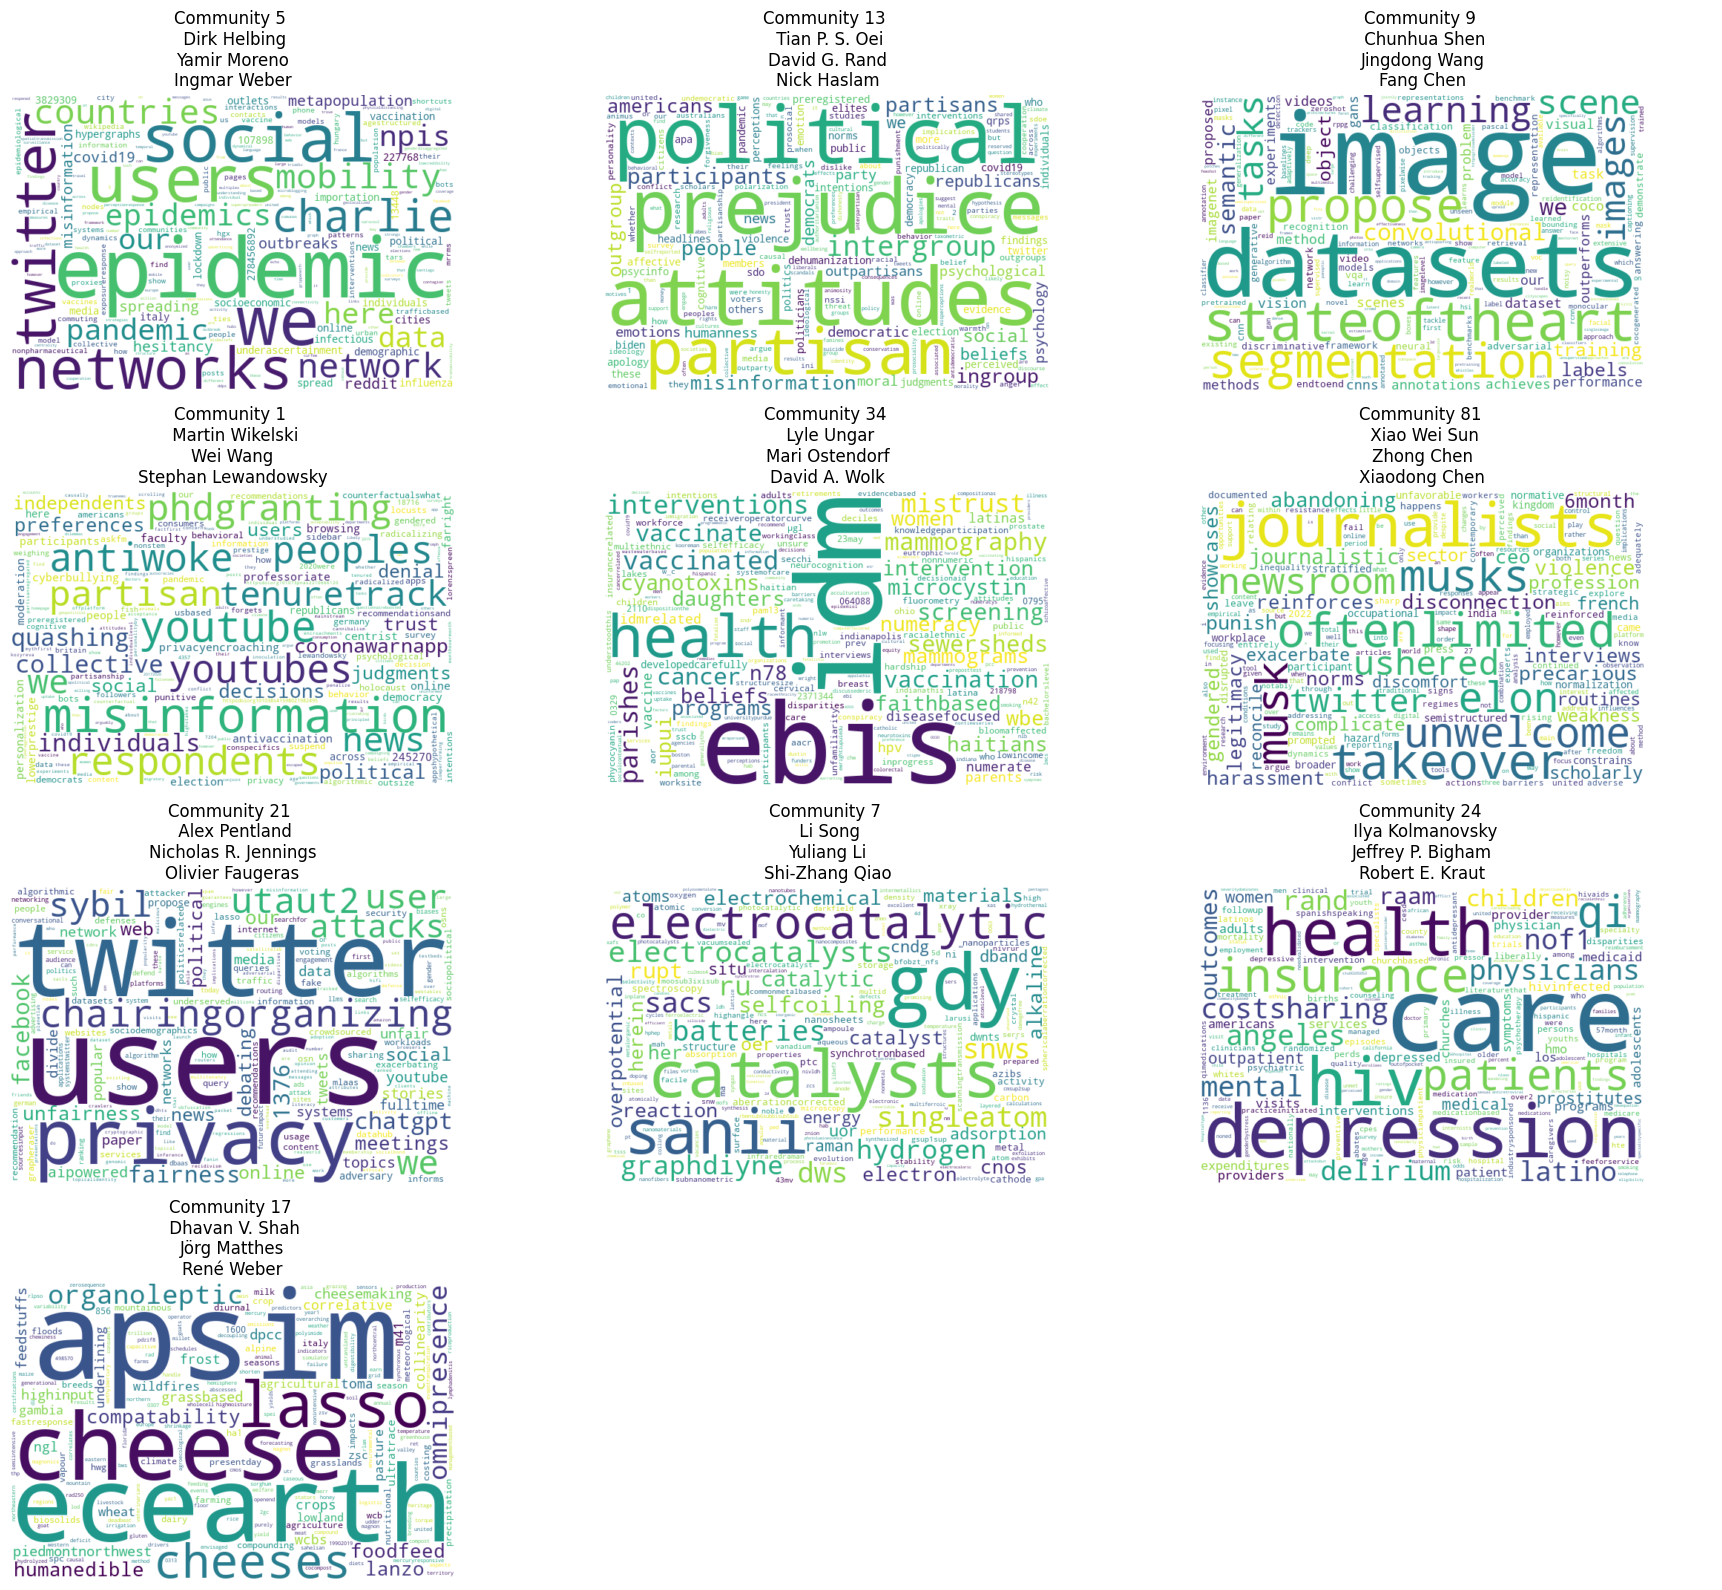

In [30]:

n = 10
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))
axes = axes.flatten()
 
for ax, (com) in tqdm(zip(axes, community_tokens.nlargest(10, "n_authors")["com"])):
    row = tfidf[tfidf.index == com].iloc[0]
    weights = row[row > 0].to_dict()
    wc = WordCloud(width=600, height=400, background_color="white")
    wc.generate_from_frequencies(weights)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Community {com} \n {"\n".join(community_tokens[community_tokens["com"] == com]["top_authors"].iloc[0])}")
    ax.axis("off")

# hide unused axes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Some of these sub-communities have more overlap with other disciplines than they do with Computational Social Science. 
It is somewhat surprising that there are subcommunities for politics, social media and politics on social media.
This shows that this subject is of heavy interest within Computational Social Science, but also that researchesr within these subcommunities are less likely to coauthor papers despite working studying similar things.

These are the results of looking up the top author in each of 10 top categories:

- Dirk Helbing: Studies network organization at Computational Social Science at ETHZ
- TIan P S Oei: Psychometrician sttudying addiction
- Chunhua Shen: CV researcher
- Martin Wikelski: An Ecologist
- Lyle Ungar: ML researcher
- Xiao Wei Sin: Physicist
- Alex Pentland: Computation Social Scientist studying social medie
- Li Song: Physicist
- Ilya Kolmanovsky: Control Systems Researcher
- Dhavan V. Shah: Social Media Researcher

In most cases these researchers are involved with the kind of work suggestions by the word clouds. However, we note that some of them are simply highly collaborative and productive scientists who more properly would belong to a different cluster (such as a subfield of physics) if research from those fields would have been included in the clustering analysis.

### Exercise 3
These findings have made ud understsand that the field of Computational Social Science is more interdisciplinary than we had expected. Many of the subfields have heavy overlap with a wide array of other scientific communities.